In [1]:
from pylab import *

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.5
Plasticnet version  0.1.14
macOS-15.5-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
base_sim_dir=f"sims-2025-06-24 figs"
if not os.path.exists(base_sim_dir):
    print("new")
    os.mkdir(base_sim_dir)
print(base_sim_dir)


sims-2025-06-24 figs


In [4]:
def default_post(number_of_neurons):
    post=pn.neurons.linear_neuron(number_of_neurons)
    post+=pn.neurons.process.sigmoid(0,50)
    return post

def default_bcm(pre,post,orthogonalization=True):
    c=pn.connections.BCM(pre,post,[-.01,.01],[.1,.2])
    
    if orthogonalization:
        c+=pn.connections.process.orthogonalization(10*minute)

    c.eta=2e-6
    c.tau=15*pn.minute   

    return c

In [5]:
def deficit(blur=[2.5,-1],noise=[0.1,0.1],rf_size=19,
            eta=2e-6,
           number_of_neurons=10,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,
           total_time=8*day*4,
           save_interval=1*hour):


    print("sigma_c",sigma_c)
    
    im=[]
    for b in blur:
        if b<0:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
        else:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'blur','size':b},
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                   rf_size=rf_size,
                                                sigma_r=0,
                                                sigma_c=0,
                                       verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],rf_size=rf_size,
                                other_channel=pre1,
                                    mu_r=mu_r,mu_c=mu_c,
                                    sigma_r=sigma_r,sigma_c=sigma_c,
                                verbose=False)

    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])

    sigma=noise
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    sim=pn.simulation(total_time)
    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi,
                            )

    return sim,[pre,post],[c]


@ray.remote
def run_one_deficit(params,run=True,overwrite=False):
    import plasticnet as pn
    eta,noise,blur,mu_c,mu_r,sigma_c,sigma_r,number_of_neurons,sfname=(
                                params.eta,
                                params.noise,
                                params.blur,
                                params.mu_c,
                                params.mu_r,
                                params.sigma_c,
                                params.sigma_r,
                                params.number_of_neurons,
                                params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                 eta=eta,
                 noise=noise,blur=blur,
                 mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,) 


    if run:
        seq.run(display_hash=False)
        pn.save(sfname,seq) 
    
    return sfname
    

In [6]:
number_of_neurons=12
eta=1e-6
number_of_processes=8
ray.init(num_cpus=number_of_processes,ignore_reinit_error=True)

2025-06-24 16:48:08,409	INFO worker.py:1888 -- Started a local Ray instance.


Python version:,3.12.6
Ray version:,2.46.0


(pid=6245) Splikes version  0.1.5
(pid=6245) Plasticnet version  0.1.14
(run_one_continuous_fix pid=6245) sigma_c 0
(run_one_continuous_fix pid=6245) [
(run_one_continuous_fix pid=6245) .
(run_one_continuous_fix pid=6245) .] Sequence Time Elapsed...17 m, 31.29 s
(run_one_continuous_fix pid=6245) sigma_c 2
(run_one_continuous_fix pid=6245) [
(run_one_continuous_fix pid=6245) .


(raylet) [2025-06-24 17:48:30,387 E 6236 7823898] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-24_16-48-07_807708_6227 is over 95% full, available space: 186.073 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-24 17:48:40,440 E 6236 7823898] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-24_16-48-07_807708_6227 is over 95% full, available space: 185.877 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-24 17:48:50,499 E 6236 7823898] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-24_16-48-07_807708_6227 is over 95% full, available space: 185.877 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-24 17:49:00,539 E 6236 7823898] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-24_16-48-07_807708_6227 is over 95% full, available space: 185.876 GB; capacity: 3721.87 GB. Object creation will fail i

(run_one_continuous_fix pid=6245) .] Sequence Time Elapsed...17 m, 30.20 s


(raylet) [2025-06-24 17:53:21,973 E 6236 7823898] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-24_16-48-07_807708_6227 is over 95% full, available space: 184.091 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-24 17:53:32,027 E 6236 7823898] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-24_16-48-07_807708_6227 is over 95% full, available space: 184.029 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-24 17:53:42,089 E 6236 7823898] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-24_16-48-07_807708_6227 is over 95% full, available space: 183.288 GB; capacity: 3721.87 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-24 17:53:52,147 E 6236 7823898] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-24_16-48-07_807708_6227 is over 95% full, available space: 182.612 GB; capacity: 3721.87 GB. Object creation will fail i

In [7]:
def fix(noise=[0.1,0.1],rf_size=19,
           number_of_neurons=10,
           total_time=8*day,
           save_interval=1*hour,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,        
           eta=2e-6):
    
    
    im=[]
    im+=[pi5.filtered_images(base_image_file,
                        {'type':'norm'},
                        {'type':'dog','sd1':1,'sd2':3},   
                        verbose=False,
                        )
        ]
    im+=[pi5.filtered_images(base_image_file,
                        {'type':'norm'},
                        {'type':'dog','sd1':1,'sd2':3},
                        verbose=False,
                        )
        ]
                     
    
    
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                        rf_size=rf_size,
                                        sigma_r=0,
                                        sigma_c=0,
                                        verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],
                                       rf_size=rf_size,
                                       other_channel=pre1,
                                       mu_r=mu_r,mu_c=mu_c,
                                       sigma_r=sigma_r,sigma_c=sigma_c,
                                       verbose=False)
    
    


    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    save_interval=save_interval

    sim=pn.simulation(total_time)

    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi)

    return sim,[pre,post],[c]

@ray.remote
def run_one_continuous_fix(params,run=True,overwrite=False):
    import plasticnet as pn
    eta,noise,mu_c,mu_r,sigma_c,sigma_r,number_of_neurons,blur,total_times,sfname=(
                                params.eta,
                                params.noise,
                                params.mu_c,
                                params.mu_r,
                                params.sigma_c,
                                params.sigma_r,
                                params.number_of_neurons,
                                params.blur,
                                params.total_time,
                                params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                 mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,
                 total_time=total_times[0],
                blur=blur) 

    seq+=fix(
             save_interval=20*minute,number_of_neurons=params.number_of_neurons,
             eta=eta,noise=noise,mu_c=mu_c,sigma_c=sigma_c,
                 total_time=total_times[1],
             mu_r=mu_r,sigma_r=sigma_r)

    if run:
        seq.run(display_hash=False)
        pn.save(sfname,seq) 
    
    return sfname
    

In [8]:
# try with a blur=4
func=run_one_continuous_fix

p=Struct()
p.eta=eta
p.number_of_neurons=number_of_neurons
p.mu_c=0
p.sigma_c=0
p.mu_r=0
p.sigma_r=0
p.blur=[4,-1]
p.noise=(.1,.1)
p.eta=2e-6
p.total_time=[8*day*4,8*day*8]
p.sfname=base_sim_dir+f"/fix mu_c={p.mu_c} sigma_c={p.sigma_c} blur={p.blur[0]}.asdf"
print(p.sfname)


sims-2025-06-24 figs/fix mu_c=0 sigma_c=0 blur=4.asdf


In [9]:
# this one is good
func=run_one_continuous_fix

p=Struct()
p.eta=eta
p.number_of_neurons=number_of_neurons
p.mu_c=0
p.sigma_c=0
p.mu_r=0
p.sigma_r=0
p.blur=[2,-1]
p.noise=(.1,.1)
p.eta=2e-6
p.total_time=[8*day*4,8*day*8]
p.sfname=base_sim_dir+f"/fix mu_c={p.mu_c} sigma_c={p.sigma_c} blur={p.blur[0]}.asdf"
print(p.sfname)


sims-2025-06-24 figs/fix mu_c=0 sigma_c=0 blur=2.asdf


In [20]:
# this one is good
func=run_one_continuous_fix

p=Struct()
p.eta=eta
p.number_of_neurons=number_of_neurons
p.mu_c=7.5
p.sigma_c=2
p.mu_r=0
p.sigma_r=0
p.blur=[2,-1]
p.noise=(.1,.1)
p.eta=2e-6
p.total_time=[8*day*4,8*day*8]
p.sfname=base_sim_dir+f"/fix mu_c={p.mu_c} sigma_c={p.sigma_c} blur={p.blur[0]}.asdf"
print(p.sfname)


sims-2025-06-24 figs/fix mu_c=7.5 sigma_c=2 blur=2.asdf


In [21]:
overwrite=True

In [22]:
if not os.path.exists(p.sfname) or overwrite:
    print("Running deficit/fix development")
    results = [func.remote(p,overwrite=True)]
    sfnames=ray.get(results)
else:
    sfnames=[p.sfname]

Running deficit/fix development


In [23]:
sfname=sfnames[0]
R=Results(sfname)

subR=Struct()
subR.t=R.t/day
t=subR.t

subR.y=R.y
subR.θ=R.θ

#idx1,idx2=[_[1] for _ in R.sequence_index]

# subR.ODI=R.ODI
subR.ORI=R.ORI
subR.theta_mat=R.theta_mat
subR.k_mat=R.k_mat
#subR.LSFV=R.LSFV
subR.SF_Var=R.SF_Var
subR.max_SF=R.max_SF
subR.sfname=sfname
subR.sequence_index=R.sequence_index
subR.idx=[0]+[_[-1] for _ in R.sequence_index]
subR.W=R.W[subR.idx,::]

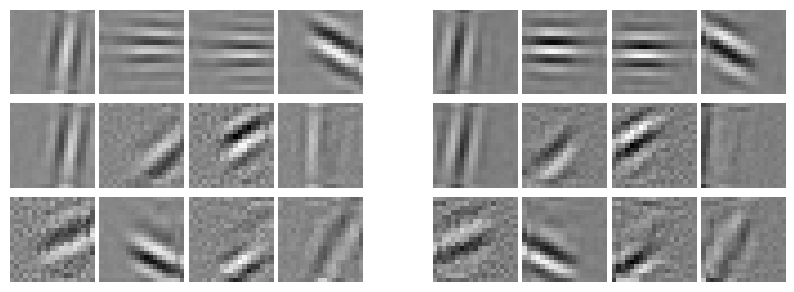

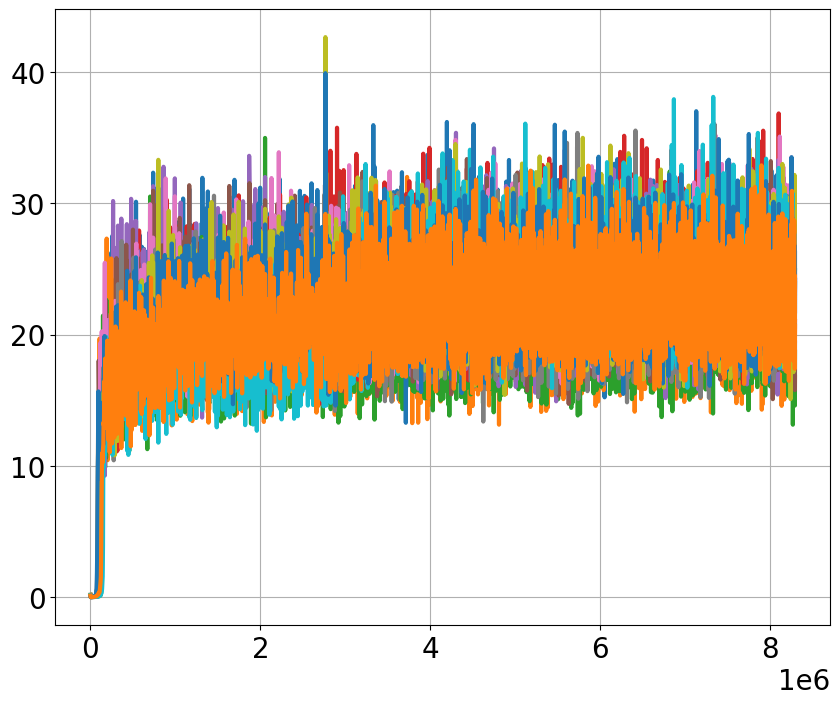

In [24]:
figure()
ims=R.W_image()

for c in range(2):
    subplot(1,2,c+1)
    imshow(ims[c],cmap=cm.gray)
    grid(None)
    axis('off')

figure()
plot(R.t,R.θ);

In [25]:
wim=R.weight_image(R.W[-1,::])
vmin,vmax=wim.min(),wim.max()
wim.shape

(12, 2, 19, 19)

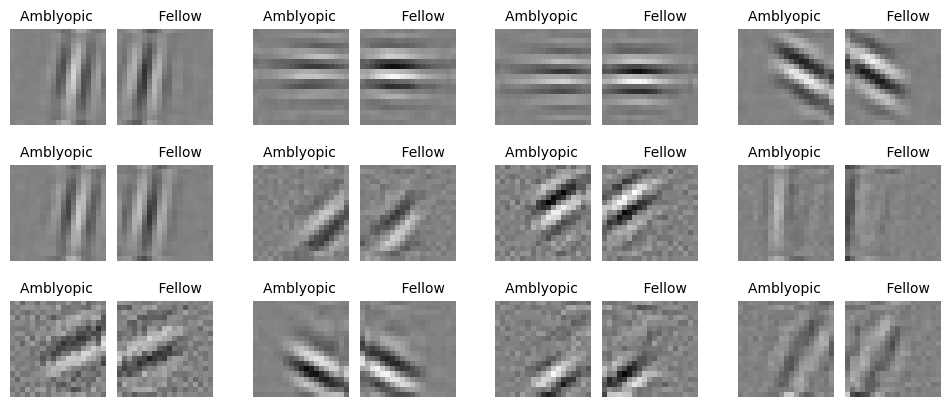

In [26]:
figure(figsize=(12,5))
for i in range(12):
    subplot(3,4,i+1)

    im=np.hstack((wim[i,0,:,:],vmax*ones((wim.shape[-1],2)),wim[i,1,:,:]))
    
    imshow(im,cmap=cm.gray,vmin=vmin,vmax=vmax)
    grid(None)
    title('Amblyopic               Fellow',size=10)
    axis('off')

In [27]:
fname=f'{base_sim_dir}/fix responses blur {p.blur[0]} noise {p.noise[1]} mu_c {p.mu_c} sigma_c {p.sigma_c}.png'
fname

'sims-2025-06-24 figs/fix responses blur 2 noise 0.1 mu_c 7.5 sigma_c 2.png'

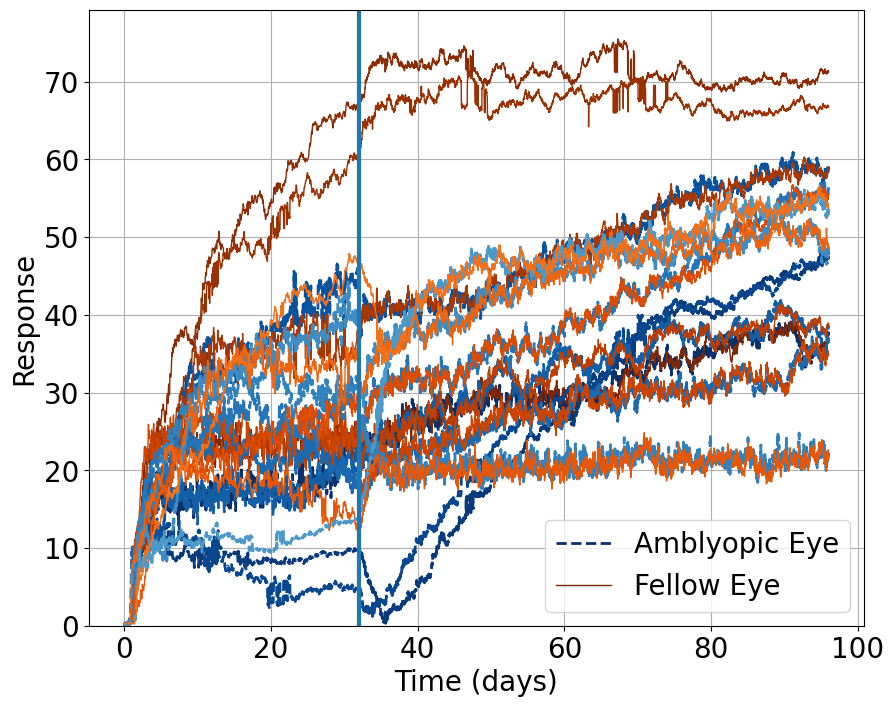

In [28]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

for n in range(10):

    if n==0:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]),label='Amblyopic Eye');
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]),label='Fellow Eye');
    else:
        plot(R.t/day,R.y[:,n,0],'--',lw=2,color=Blues2(v[n]));
        plot(R.t/day,R.y[:,n,1],'-',lw=1,color=Oranges2(v[n]));


ylabel('Response')
xlabel('Time (days)')
legend()

ylim=gca().get_ylim()
ylim=[0,ylim[1]]
vlines(R.sequence_times[1][0]/day,*ylim)
gca().set_ylim(ylim)

fname=f'{base_sim_dir}/fix responses blur {p.blur[0]} noise {p.noise[1]} mu_c {p.mu_c} sigma_c {p.sigma_c}.pdf'
plt.savefig(fname,bbox_inches='tight')

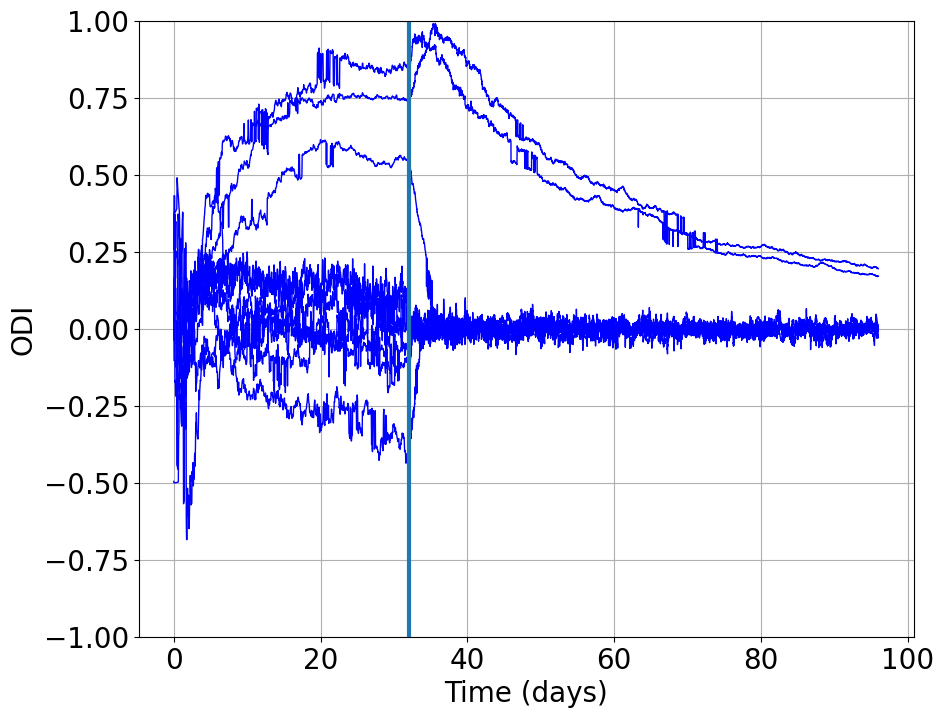

In [29]:
Blues2 = truncate_colormap(mpl.cm.Blues, 0.3, 1.0)
Oranges2 = truncate_colormap(mpl.cm.Oranges, 0.3, 1.0)
v=np.flip(linspace(0.3,1,number_of_neurons))

plot(R.t/day,R.ODI[:,:10],'b-',lw=1);

gca().set_ylim([-1,1])
ylim=gca().get_ylim()
vlines(R.sequence_times[1][0]/day,*ylim)

ylabel('ODI')
xlabel('Time (days)')

fname=f'{base_sim_dir}/fix ODI blur {p.blur[0]} noise {p.noise[1]} mu_c {p.mu_c} sigma_c {p.sigma_c}.pdf'
plt.savefig(fname,bbox_inches='tight')